In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from itertools import product
import pathlib as pth

from minigrad.tensor import Tensor
from minigrad.nn import Sequential, Linear, Perceptron, Sigmoid, Softmax
from minigrad.nn.losses import categorical_cross_entropy
from minigrad.optim import GD, SGD

In [2]:
# Specify the path to our CSV files
data_dir = pth.Path('data')
train_path = data_dir / 'fashion-mnist_train.csv'
test_path = data_dir / 'fashion-mnist_test.csv'

# 1. Load data via pandas
print("Loading data...")
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# In these CSVs, the first column is named 'label' (the correct answer from 0 to 9),
# and the remaining 784 columns are the image pixels (28x28).

# 2. Separate labels (y) from features/pixels (X)
y_train_raw = df_train['label'].values
X_train_raw = df_train.drop('label', axis=1).values

y_test_raw = df_test['label'].values
X_test_raw = df_test.drop('label', axis=1).values

# 3. Normalization (Task point 2)
# Pixels have values from 0 to 255. Neural networks struggle with such large numbers.
# Divide by 255.0 so that all values are in the range from 0.0 to 1.0.
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0

# 4. One-Hot Encoding for labels
# Our categorical_cross_entropy loss function expects One-Hot format.
# For example, class 3 will turn into [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
num_classes = 10
y_train = np.eye(num_classes)[y_train_raw]
y_test = np.eye(num_classes)[y_test_raw]

print("\nPreparation complete!")
print("X_train shape:", X_train.shape) # Should be (60000, 784)
print("y_train shape:", y_train.shape) # Should be (60000, 10)
print("X_test shape:", X_test.shape)   # Should be (10000, 784)
print("y_test shape:", y_test.shape)   # Should be (10000, 10)

Loading data...

Preparation complete!
X_train shape: (60000, 784)
y_train shape: (60000, 10)
X_test shape: (10000, 784)
y_test shape: (10000, 10)


In [3]:
# ==========================================
# Evaluation Metrics and Validation Function
# ==========================================

def calculate_accuracy(y_pred: np.ndarray, y_true_raw: np.ndarray) -> float:
    """
    Calculate accuracy given raw probabilities and raw target labels.
    """
    # Find the index of the highest probability class (0-9)
    predictions = np.argmax(y_pred, axis=1)
    # Compare with raw labels and compute the mean match rate
    return float(np.mean(predictions == y_true_raw))

def evaluate_model(model, X: np.ndarray, y_onehot: np.ndarray, y_raw: np.ndarray, loss_fn, batch_size: int = 32):
    """
    Evaluate the model on a dataset without updating weights (no backprop).
    """
    n_samples = X.shape[0]
    total_loss = 0.0
    all_preds = []

    for start in range(0, n_samples, batch_size):
        end = start + batch_size
        
        # requires_grad=False because we don't need gradients for evaluation
        x_batch = Tensor(X[start:end], requires_grad=False)
        y_batch = Tensor(y_onehot[start:end], requires_grad=False)

        # Forward pass only
        y_pred_tensor = model(x_batch)
        loss = loss_fn(y_pred_tensor, y_batch)

        total_loss += loss.item()
        all_preds.append(y_pred_tensor.data)

    # Calculate average loss
    avg_loss = total_loss / (n_samples / batch_size)
    
    # Concatenate all batch predictions to calculate overall accuracy
    full_preds = np.vstack(all_preds)
    accuracy = calculate_accuracy(full_preds, y_raw)

    return avg_loss, accuracy

In [4]:
# ==========================================
# Model Definition and Training Loop
# ==========================================

from minigrad.nn import Sequential, Linear, ReLU, Softmax
from minigrad.nn.losses import categorical_cross_entropy
from minigrad.optim import SGD
from minigrad.utils.training import train_epoch

# Define base model (Task point 4: one hidden layer and softmax)
# 784 inputs (28x28 pixels) -> 128 hidden neurons -> 10 output classes
model = Sequential(
    Linear(784, 128),
    ReLU(),
    Linear(128, 10),
    Softmax()
)

# Task point 10: Hyperparameter for learning rate
learning_rate = 0.1
optimizer = SGD(model.parameters(), lr=learning_rate)

epochs = 15
batch_size = 64

# Dictionaries to store metrics for plotting (Task point 9)
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print("Starting training...")
for epoch in range(epochs):
    # 1. Train for one epoch (updates weights)
    train_loss = train_epoch(model, X_train, y_train, categorical_cross_entropy, optimizer, batch_size)

    # 2. Evaluate on train set to get accuracy
    _, train_acc = evaluate_model(model, X_train, y_train, y_train_raw, categorical_cross_entropy, batch_size)

    # 3. Evaluate on validation (test) set
    val_loss, val_acc = evaluate_model(model, X_test, y_test, y_test_raw, categorical_cross_entropy, batch_size)

    # 4. Save metrics for plotting later
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Starting training...
Epoch 01/15 | Train Loss: 0.5789 | Train Acc: 0.8305 | Val Loss: 0.4838 | Val Acc: 0.8306
Epoch 02/15 | Train Loss: 0.4279 | Train Acc: 0.8379 | Val Loss: 0.4443 | Val Acc: 0.8333
Epoch 03/15 | Train Loss: 0.3875 | Train Acc: 0.8700 | Val Loss: 0.3776 | Val Acc: 0.8689
Epoch 04/15 | Train Loss: 0.3610 | Train Acc: 0.8752 | Val Loss: 0.3683 | Val Acc: 0.8698
Epoch 05/15 | Train Loss: 0.3454 | Train Acc: 0.8722 | Val Loss: 0.3726 | Val Acc: 0.8652
Epoch 06/15 | Train Loss: 0.3287 | Train Acc: 0.8801 | Val Loss: 0.3546 | Val Acc: 0.8710
Epoch 07/15 | Train Loss: 0.3182 | Train Acc: 0.8807 | Val Loss: 0.3622 | Val Acc: 0.8699
Epoch 08/15 | Train Loss: 0.3064 | Train Acc: 0.8915 | Val Loss: 0.3371 | Val Acc: 0.8791
Epoch 09/15 | Train Loss: 0.2975 | Train Acc: 0.8663 | Val Loss: 0.4163 | Val Acc: 0.8523
Epoch 10/15 | Train Loss: 0.2900 | Train Acc: 0.8926 | Val Loss: 0.3400 | Val Acc: 0.8755
Epoch 11/15 | Train Loss: 0.2825 | Train Acc: 0.8915 | Val Loss: 0.3360 | Val A

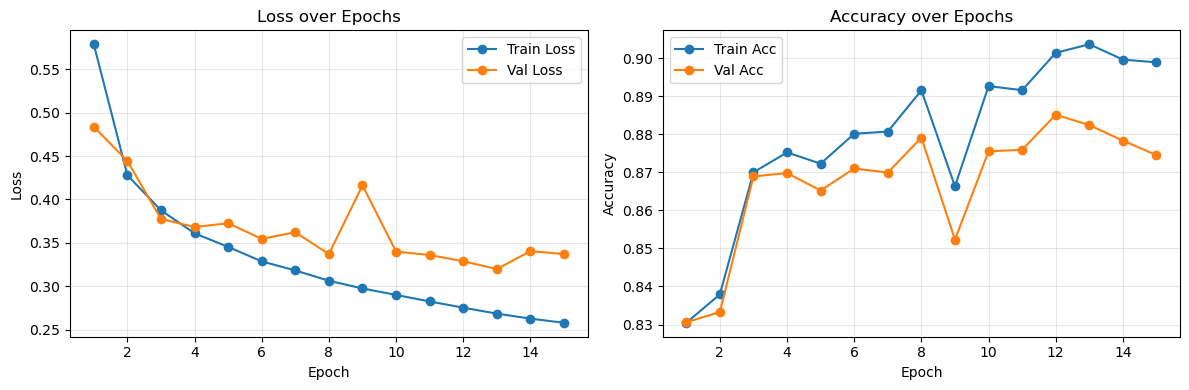


Total incorrect predictions: 1255 out of 10000


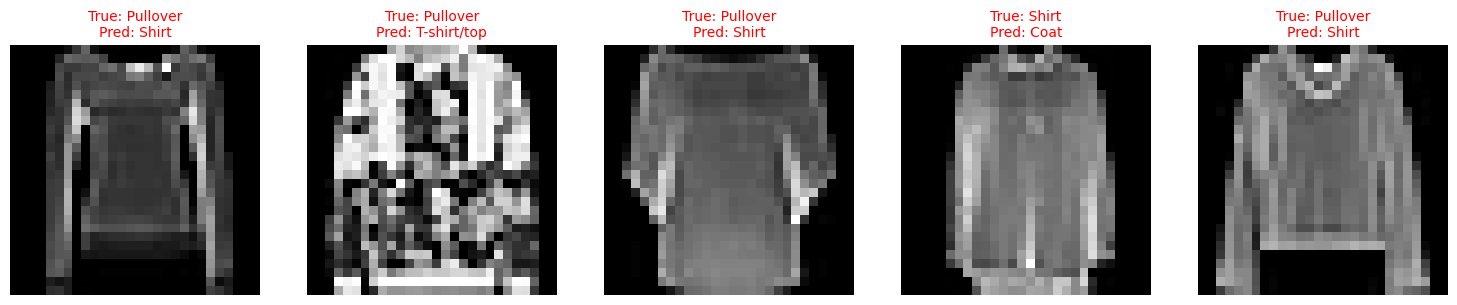

In [5]:
from minigrad.utils.visualization import plot_history, plot_misclassified

# 1. Plot History (Task point 9)
plot_history(history)

# 2. Plot Mistakes (Task point 12)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plot_misclassified(model, X_test, X_test_raw, y_test_raw, class_names)